In [5]:
import pandas as pd, numpy as np, sklearn, lightgbm, scipy, statsmodels, matplotlib.pyplot as plt, seaborn
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

## Первая часть


In [6]:
df = pd.read_json('train.json')
print(f'кол-во строк: {df.shape[0]}, кол-во столбцов: {df.shape[1]}')

df.head()
print("цель: df['price']")


кол-во строк: 49352, кол-во столбцов: 15
цель: df['price']


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49352 entries, 4 to 124009
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   bathrooms        49352 non-null  float64
 1   bedrooms         49352 non-null  int64  
 2   building_id      49352 non-null  object 
 3   created          49352 non-null  object 
 4   description      49352 non-null  object 
 5   display_address  49352 non-null  object 
 6   features         49352 non-null  object 
 7   latitude         49352 non-null  float64
 8   listing_id       49352 non-null  int64  
 9   longitude        49352 non-null  float64
 10  manager_id       49352 non-null  object 
 11  photos           49352 non-null  object 
 12  price            49352 non-null  int64  
 13  street_address   49352 non-null  object 
 14  interest_level   49352 non-null  object 
dtypes: float64(3), int64(3), object(9)
memory usage: 6.0+ MB


In [8]:
df.describe()

,bathrooms,bedrooms,latitude,listing_id,longitude,price
count,49352.00000,49352.000000,49352.000000,4.935200e+04,49352.000000,4.935200e+04
mean,1.21218,1.541640,40.741545,7.024055e+06,-73.955716,3.830174e+03
std,0.50142,1.115018,0.638535,1.262746e+05,1.177912,2.206687e+04
min,0.00000,0.000000,0.000000,6.811957e+06,-118.271000,4.300000e+01
25%,1.00000,1.000000,40.728300,6.915888e+06,-73.991700,2.500000e+03
50%,1.00000,1.000000,40.751800,7.021070e+06,-73.977900,3.150000e+03
75%,1.00000,2.000000,40.774300,7.128733e+06,-73.954800,4.100000e+03
max,10.00000,8.000000,44.883500,7.753784e+06,0.000000,4.490000e+06


In [9]:
df_with_numbers = df[['bathrooms', 'bedrooms', 'latitude','listing_id','longitude','price']]

display(df_with_numbers.corr())
print("Сильно коррелируют только долгота и широта")

,bathrooms,bedrooms,latitude,listing_id,longitude,price
bathrooms,1.000000,0.533446,-0.009657,0.000776,0.010393,0.069661
bedrooms,0.533446,1.000000,-0.004745,0.011968,0.006892,0.051788
latitude,-0.009657,-0.004745,1.000000,0.001712,-0.966807,-0.000707
listing_id,0.000776,0.011968,0.001712,1.000000,-0.000907,0.008090
longitude,0.010393,0.006892,-0.966807,-0.000907,1.000000,-0.000087
price,0.069661,0.051788,-0.000707,0.008090,-0.000087,1.000000


Сильно коррелируют только долгота и широта


In [10]:
df.isna().sum()

bathrooms          0
bedrooms           0
building_id        0
created            0
description        0
display_address    0
features           0
latitude           0
listing_id         0
longitude          0
manager_id         0
photos             0
price              0
street_address     0
interest_level     0
dtype: int64

In [11]:
df = df[['bathrooms','bedrooms','interest_level','price']]

## Вторая часть

price
2500      1106
3200       881
3000       840
2700       777
2400       772
          ... 
5753         1
2417         1
9625         1
5433         1
135000       1
Name: count, Length: 2808, dtype: int64

43 4490000


Text(0.5, 1.0, 'Распределение цены до удаления выбросов')

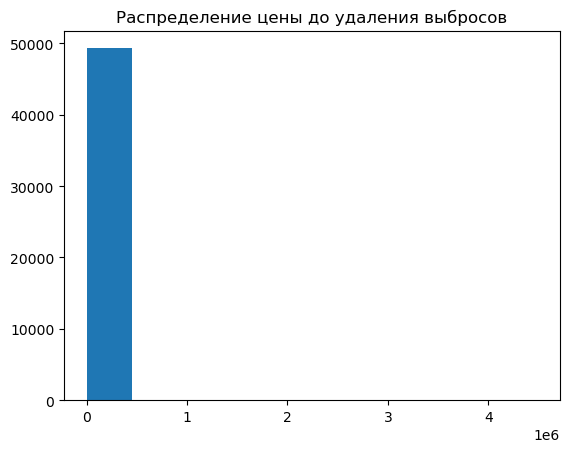

In [12]:
display(df['price'].value_counts())
print(df['price'].min(), df['price'].max())

plt.hist(df['price'])
plt.title('Распределение цены до удаления выбросов')

Есть несколько выбросов


Text(0.5, 1.0, 'Определение выбросов цены')

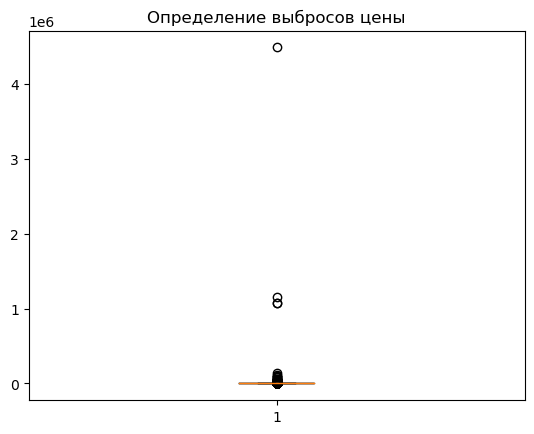

In [13]:
plt.boxplot(df['price'])
print("Есть несколько выбросов")
plt.title('Определение выбросов цены')

In [14]:
lower = df['price'].quantile(0.01)
upper = df['price'].quantile(0.99)

df = df[(df['price'] >= lower) & (df['price'] <= upper)]

Text(0.5, 1.0, 'Распределение цены')

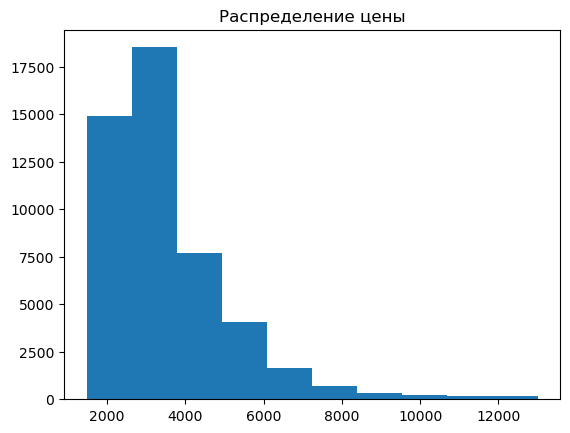

In [15]:
plt.hist(df['price'])
plt.title('Распределение цены')

Мы удалили выбросы(значения, которые либо слишком завышены, либо слишком занижены) и теперь график наглядно отображает реальное распределение данных.

In [16]:
df.info()

df['interest_level'].value_counts()

df['interest_level'] = LabelEncoder().fit_transform(df['interest_level'])

<class 'pandas.core.frame.DataFrame'>
Index: 48379 entries, 4 to 124009
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   bathrooms       48379 non-null  float64
 1   bedrooms        48379 non-null  int64  
 2   interest_level  48379 non-null  object 
 3   price           48379 non-null  int64  
dtypes: float64(1), int64(2), object(1)
memory usage: 1.8+ MB


Text(0.5, 1.0, 'Распределение комнат ванной')

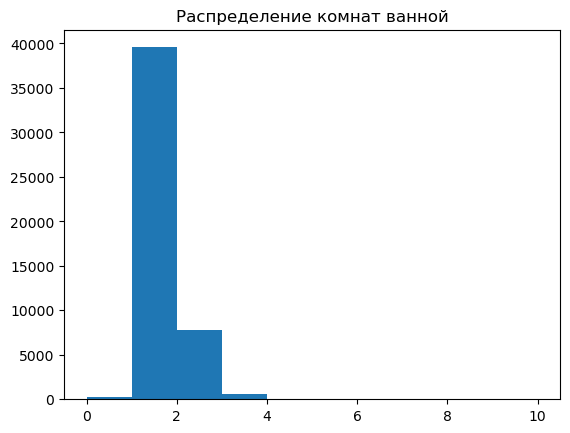

In [17]:
plt.hist(df['bathrooms'])
plt.title('Распределение комнат ванной')

Text(0.5, 1.0, 'Распределение комнат спален')

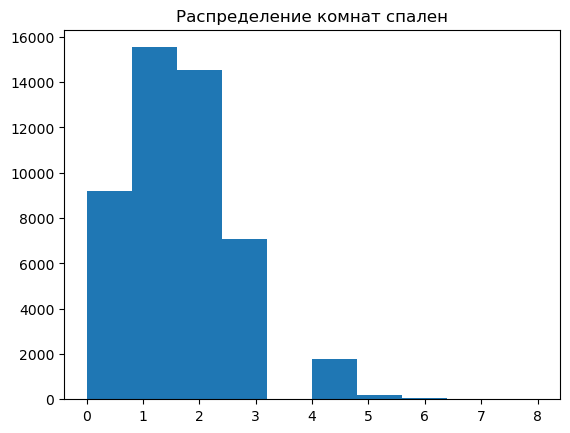

In [18]:
plt.hist(df['bedrooms'])
plt.title('Распределение комнат спален')

In [19]:
df.corr()

,bathrooms,bedrooms,interest_level,price
bathrooms,1.000000,0.517574,-0.006578,0.671943
bedrooms,0.517574,1.000000,0.028754,0.545948
interest_level,-0.006578,0.028754,1.000000,-0.033239
price,0.671943,0.545948,-0.033239,1.000000


Text(0.5, 1.0, 'Матрица корреляции')

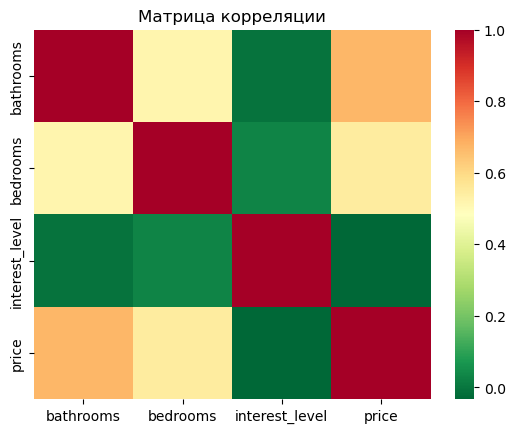

In [20]:
sns.heatmap(df.corr(),cmap='RdYlGn_r')
plt.title('Матрица корреляции')


Между ценой и кол-вом комнат в ванной наибольшая корреляция 0.67

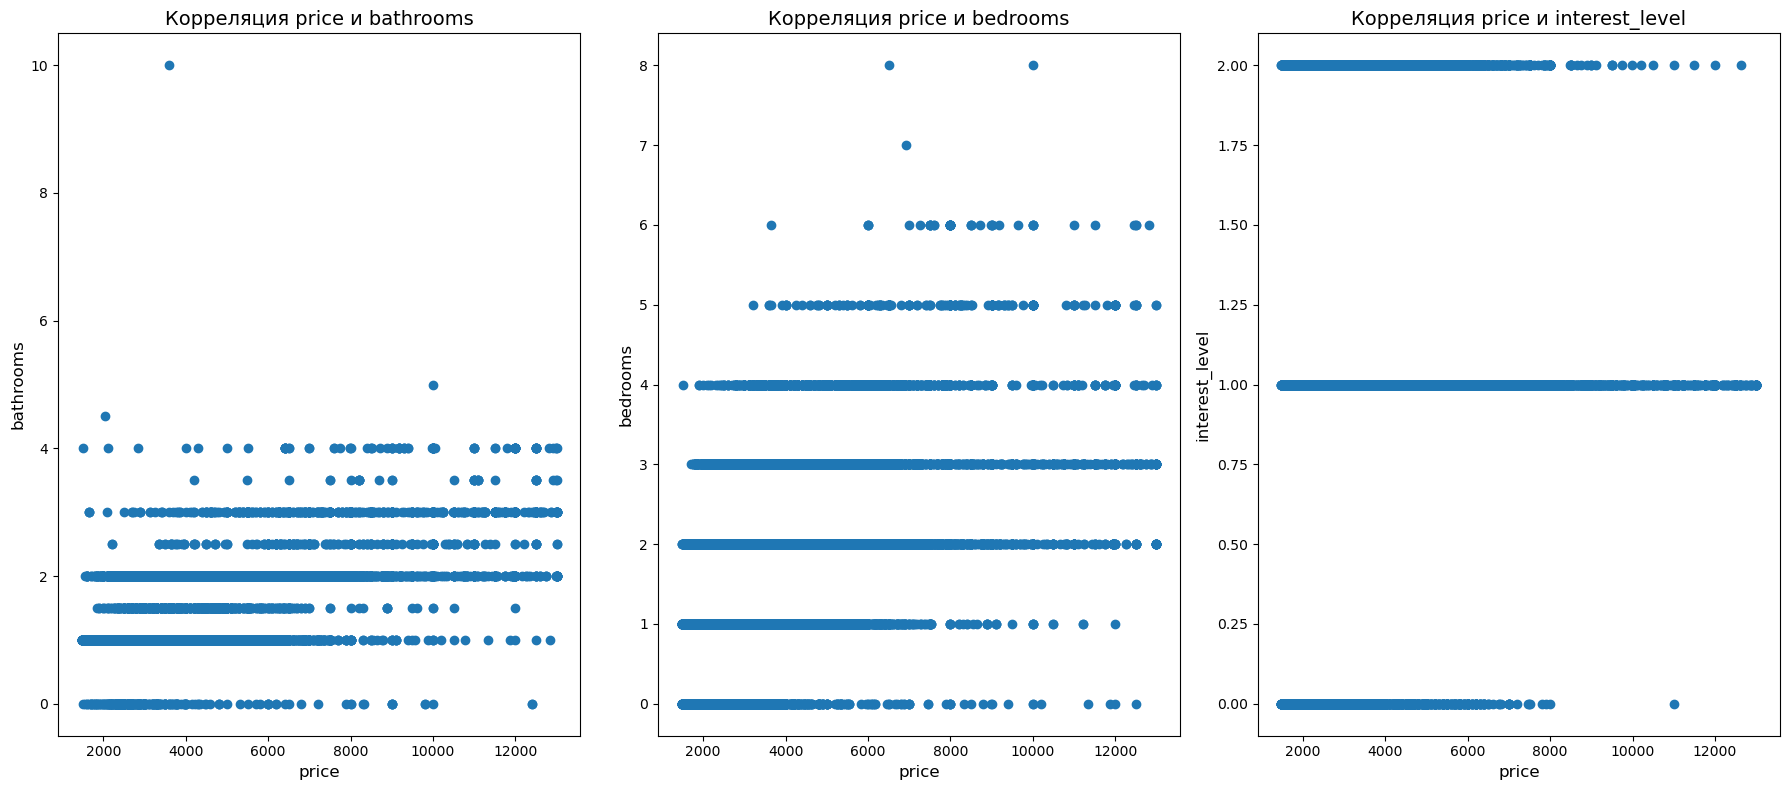

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

features = ['bathrooms', 'bedrooms', 'interest_level'] 

for i, feature in enumerate(features):
    axes[i].scatter(df['price'],df[feature])
    axes[i].set_xlabel('price', fontsize=12)
    axes[i].set_ylabel(feature, fontsize=12)
    axes[i].set_title(f'Корреляция price и {feature}', fontsize=14)
    

plt.tight_layout()
plt.show()

## Третья часть

In [22]:
df_features_squared = df.copy()

features = ['bathrooms', 'bedrooms', 'interest_level'] 

for i in features:
    df_features_squared[i] = df_features_squared[i] ** 2

In [23]:
df_features_squared.corr()
# Новые признаки коррелируют незначительно меньше в среднем. 

,bathrooms,bedrooms,interest_level,price
bathrooms,1.000000,0.522227,-0.032822,0.648486
bedrooms,0.522227,1.000000,0.040017,0.543406
interest_level,-0.032822,0.040017,1.000000,-0.092995
price,0.648486,0.543406,-0.092995,1.000000


In [24]:
df = df.drop(['interest_level'], axis = 1)

In [25]:
X = df.drop(['price'], axis = 1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [26]:
X_train_df = X_train.copy()  
X_test_df = X_test.copy()    

poly = PolynomialFeatures(degree=10)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [27]:
feature_names = poly.get_feature_names_out(X_train_df.columns)
X_train_poly  = pd.DataFrame(X_train_poly, columns=feature_names, index=X_train_df.index)
X_test_poly = pd.DataFrame(X_test_poly, columns=feature_names, index=X_test_df.index)

## Четвертая часть

In [28]:
result_MAE = pd.DataFrame(columns = ['model', 'train', 'test'])
result_RMSE = pd.DataFrame(columns = ['model', 'train', 'test'])

In [29]:
lr = LinearRegression()

lr.fit(X_train_poly, y_train)

y_train_pred_lr = lr.predict(X_train_poly)
y_test_pred_lr = lr.predict(X_test_poly)

mae_train = mean_absolute_error(y_train, y_train_pred_lr)
mae_test = mean_absolute_error(y_test, y_test_pred_lr)

rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred_lr))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred_lr))

result_MAE.loc[0] = ['linear_regression', mae_train, mae_test]
result_RMSE.loc[0] = ['linear_regression', rmse_train, rmse_test]




In [30]:
rt = DecisionTreeRegressor(random_state = 21)

rt.fit(X_train_poly, y_train)

y_train_pred_rt = rt.predict(X_train_poly)
y_test_pred_rt = rt.predict(X_test_poly)

mae_train_rt = mean_absolute_error(y_train, y_train_pred_rt)
mae_test_rt = mean_absolute_error(y_test, y_test_pred_rt)

rmse_train_rt = np.sqrt(mean_squared_error(y_train, y_train_pred_rt))
rmse_test_rt = np.sqrt(mean_squared_error(y_test, y_test_pred_rt))

result_MAE.loc[1] = ['decision_tree', mae_train_rt, mae_test_rt]
result_RMSE.loc[1] = ['decision_tree', rmse_train_rt, rmse_test_rt]

In [31]:
y_train_mean_pred = [y_train.mean()] * len(y_train)
y_test_mean_pred = [y_train.median()] * len(y_test)

y_train_median_pred = [y_train.mean()] * len(y_train)
y_test_median_pred = [y_train.median()] * len(y_test)

mae_train_mean = mean_absolute_error(y_train, y_train_mean_pred)
mae_test_mean = mean_absolute_error(y_test, y_test_mean_pred)

rmse_train_mean = np.sqrt(mean_squared_error(y_train, y_train_mean_pred))
rmse_test_mean = np.sqrt(mean_squared_error(y_test, y_test_mean_pred))



mae_train_median = mean_absolute_error(y_train, y_train_median_pred)
mae_test_median = mean_absolute_error(y_test, y_test_median_pred)

rmse_train_median = np.sqrt(mean_squared_error(y_train, y_train_median_pred))
rmse_test_median = np.sqrt(mean_squared_error(y_test, y_test_median_pred))


result_MAE.loc[2] = ['naive_mean', mae_train_mean, mae_test_mean]
result_MAE.loc[3] = ['naive_median', mae_train_median, mae_test_median]

result_RMSE.loc[2] = ['naive_mean', rmse_train_mean, rmse_test_mean]
result_RMSE.loc[3] = ['naive_median', rmse_train_median, rmse_test_median]

In [32]:
display(result_MAE)

,model,train,test
0,linear_regression,753.643778,7.993756e+06
1,decision_tree,753.643778,7.661802e+02
2,naive_mean,1132.944652,1.107670e+03
3,naive_median,1132.944652,1.107670e+03


In [33]:
display(result_RMSE)

,model,train,test
0,linear_regression,1072.141500,7.862436e+08
1,decision_tree,1072.141500,1.102726e+03
2,naive_mean,1587.029585,1.691333e+03
3,naive_median,1587.029585,1.691333e+03
